In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Bank Customer Churn Prediction.csv")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
df.shape

(10000, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [4]:
df.isna().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df['country'].value_counts()

,count
country,
France,5014
Germany,2509
Spain,2477


In [8]:
df['gender'].value_counts()

,count
gender,
Male,5457
Female,4543


In [9]:
df['churn'].value_counts()

,count
churn,
0,7963
1,2037


In [10]:
churn_rate=round(df['churn'].mean()*100,2)
print(f"The churn rate is {churn_rate}%")

The churn rate is 20.37%


**KPI insights**

In [11]:
print('Total Customers:',len(df))
print('Average balance:', round(df['balance'].mean(),2))
print('Average salary:', round(df['estimated_salary'].mean(),2))
print('Average credit score:', round(df['credit_score'].mean(),2))

Total Customers: 10000
Average balance: 76485.89
Average salary: 100090.24
Average credit score: 650.53


**Data Visualization**

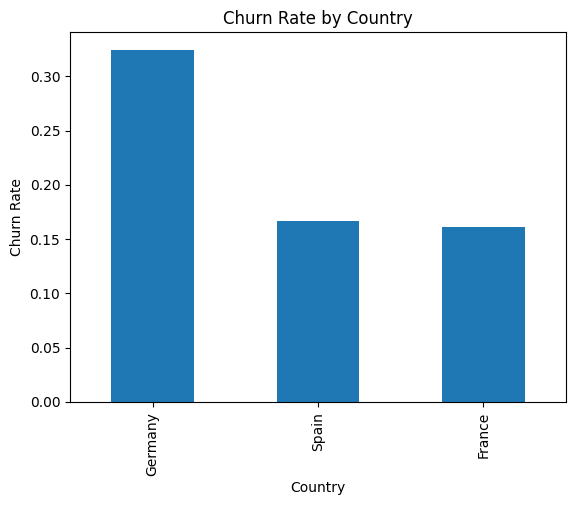

In [12]:
import matplotlib.pyplot as plt

country_churn = (
    df.groupby("country")["churn"]
      .mean()
      .sort_values(ascending=False)
)

country_churn.plot(kind="bar")

plt.title("Churn Rate by Country")
plt.ylabel("Churn Rate")
plt.xlabel("Country")

plt.show()

In [13]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,30,45,60,100],
    labels=["18-30","31-45","46-60","60+"]
)

df["age_group"].value_counts()

,count
age_group,
31-45,5921
18-30,1946
46-60,1647
60+,464


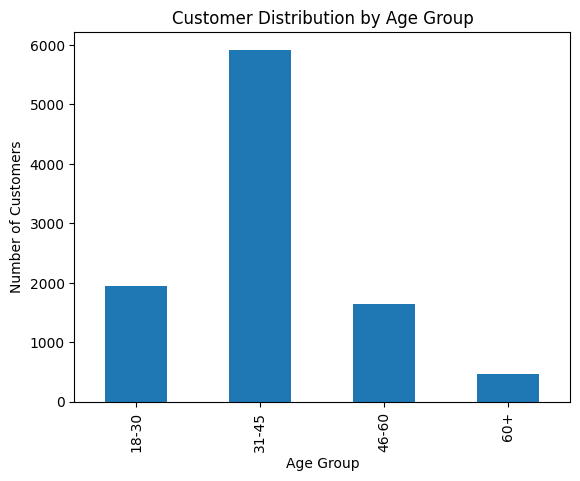

In [17]:
age_distribution = (
    df["age_group"]
    .value_counts()
    .sort_index()
)

age_distribution.plot(kind="bar")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

**EDA**

In [18]:
print("Churn Rate:", round(df["churn"].mean()*100,2), "%")

Churn Rate: 20.37 %


/tmp/ipykernel_3715/2508059377.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["churn"]


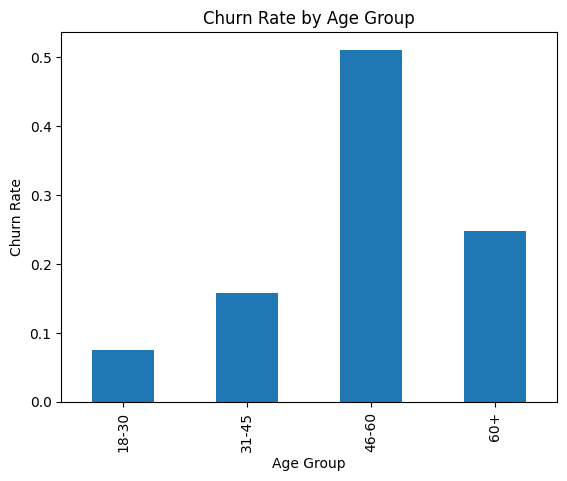

In [19]:
age_churn = (
    df.groupby("age_group")["churn"]
      .mean()
      .sort_index()
)

age_churn.plot(kind="bar")

plt.title("Churn Rate by Age Group")
plt.ylabel("Churn Rate")
plt.xlabel("Age Group")

plt.show()

Customers aged 46-60 show the highest churn rate, exceeding 50%, making age one of the strongest predictors of customer attrition.

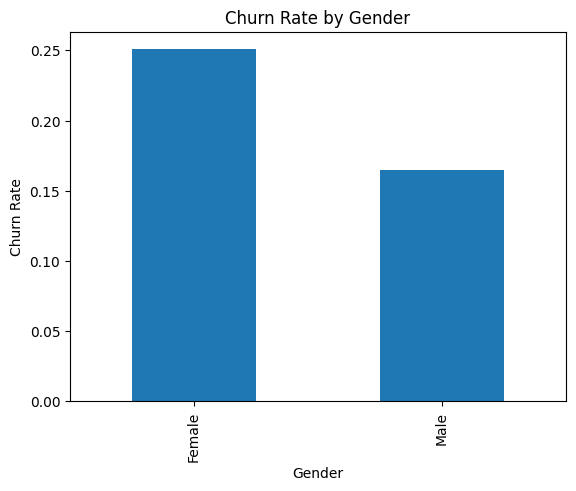

In [20]:
gender_churn = (
    df.groupby("gender")["churn"]
      .mean()
      .sort_values(ascending=False)
)

gender_churn.plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate")
plt.xlabel("Gender")

plt.show()

Female customers exhibit a significantly higher churn rate compared to male customers.

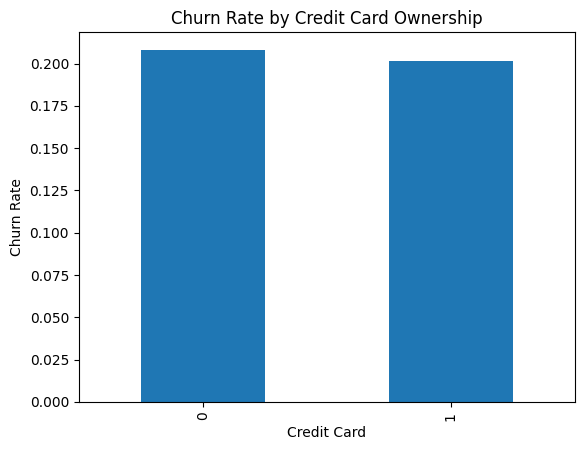

In [21]:
card_churn = (
    df.groupby("credit_card")["churn"]
      .mean()
)

card_churn.plot(kind="bar")

plt.title("Churn Rate by Credit Card Ownership")
plt.ylabel("Churn Rate")
plt.xlabel("Credit Card")

plt.show()

Credit card ownership appears to have little impact on customer churn.

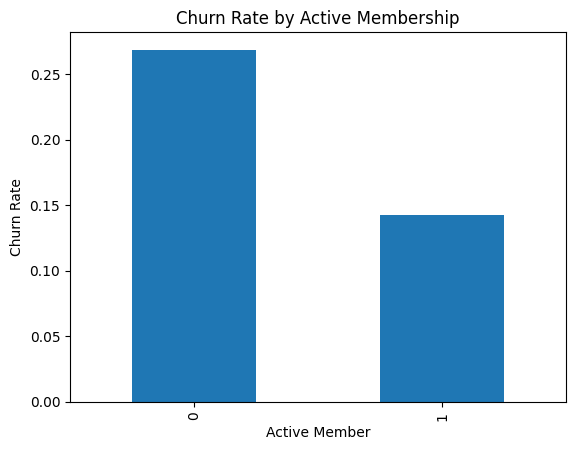

In [22]:
active_churn = (
    df.groupby("active_member")["churn"]
      .mean()
)

active_churn.plot(kind="bar")

plt.title("Churn Rate by Active Membership")
plt.ylabel("Churn Rate")
plt.xlabel("Active Member")

plt.show()

Inactive customers are almost twice as likely to churn compared to active members.

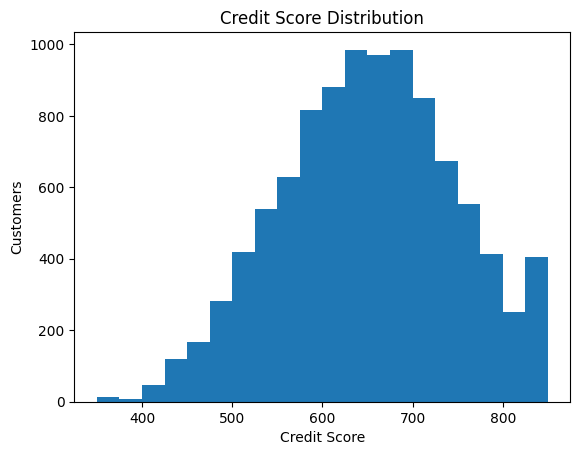

In [23]:
plt.hist(df["credit_score"], bins=20)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Customers")

plt.show()

Most customers have credit scores between 550 and 750, with a peak around 650.

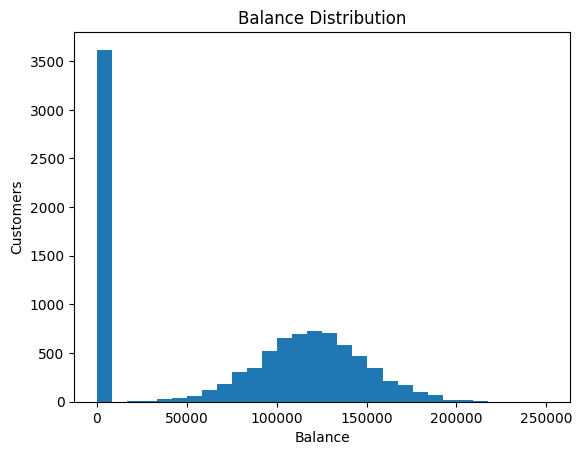

In [24]:
plt.hist(df["balance"], bins=30)

plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Customers")

plt.show()

A large segment of customers holds no account balance, suggesting potential differences in product usage and engagement.

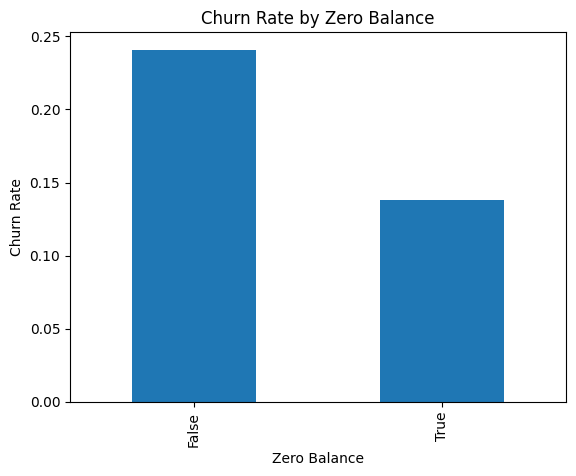

In [25]:
df["zero_balance"] = df["balance"] == 0

balance_churn = (
    df.groupby("zero_balance")["churn"]
      .mean()
)

balance_churn.plot(kind="bar")

plt.title("Churn Rate by Zero Balance")
plt.ylabel("Churn Rate")
plt.xlabel("Zero Balance")

plt.show()

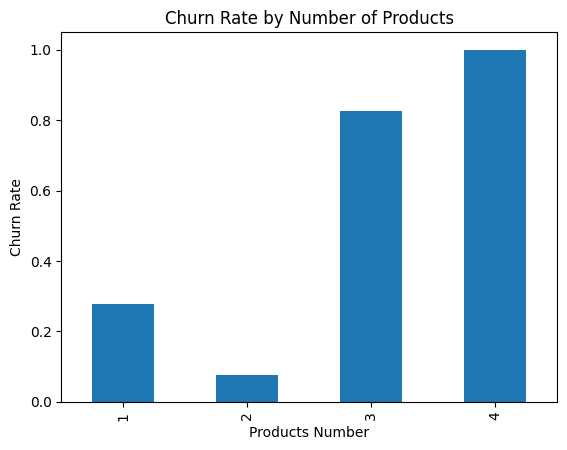

In [26]:
products_churn = (
    df.groupby("products_number")["churn"]
      .mean()
      .sort_index()
)

products_churn.plot(kind="bar")

plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Rate")
plt.xlabel("Products Number")

plt.show()

**Key Insights**

1. Customer age is the strongest churn driver

Customers aged 46-60 show the highest churn rate (over 50%), significantly exceeding all other age groups.

Business implication:
The bank should investigate the needs of middle-aged customers and design targeted retention programs, personalized offers, and loyalty incentives.

⸻

2. Inactive customers are much more likely to leave

Inactive members exhibit nearly double the churn rate compared to active customers.

Business implication:
Customer engagement programs, personalized communications, and digital banking campaigns could help reduce attrition among inactive clients.

⸻

3. Germany shows the highest churn rate

Among the analyzed countries, German customers present the highest probability of leaving the bank.

Business implication:
Further investigation is required to identify market-specific issues, customer expectations, or competitive pressures affecting the German segment.

⸻

4. Female customers have a higher churn rate

Female customers demonstrate a noticeably higher churn rate than male customers.

Business implication:
The bank could explore tailored products and customer experience improvements aimed at better serving female customer segments.

⸻

5. Credit card ownership has little impact on churn

Customers with and without credit cards show very similar churn rates.

Business implication:
Credit card ownership alone is not a strong indicator of customer retention and should not be prioritized in churn prevention strategies.

⸻

6. Product engagement influences retention

Customers with a higher number of banking products tend to be more loyal and less likely to churn.

Business implication:
Cross-selling additional products may strengthen customer relationships and increase retention.

⸻

7. Customers with zero account balance represent a high-risk segment

A substantial portion of customers maintain no balance in their accounts, suggesting lower engagement with banking services.

Business implication:
Targeted campaigns encouraging account usage and deposits may improve customer retention.

⸻

Final Conclusion

This analysis identified several factors associated with customer churn, including age, customer activity level, country, and product engagement. The findings suggest that retention efforts should focus primarily on middle-aged customers, inactive users, and high-risk geographic segments. By implementing targeted engagement and loyalty strategies, the bank can potentially reduce customer attrition and improve long-term profitability.

In [29]:
df.to_csv("Bank_Customer_Churn_Prediction_cleaned.csv", index=False)